## Libraries

In [82]:
# dataset
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# models
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.svm import SVC
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, DBSCAN, OPTICS, AgglomerativeClustering
from sklearn.metrics.pairwise import rbf_kernel

# evals
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, auc
)
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# preprocessing
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize

# dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# training
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid, GridSearchCV, RandomizedSearchCV

## Configs

In [ ]:
visualization = True
compare_features = True
grid_search = True

## 1. Models & Evaluations Implementation

### 1.1 Classification Training

In [19]:
def train_model(X_train, y_train, method='rf', **kwargs):

    method = method.lower()
    
    if method == 'logistic':
        params = {
            "class_weight": "balanced"
        }

        model = LogisticRegression(**params, **kwargs)

    elif method == 'perceptron':
        model = Perceptron(**kwargs)

    elif method == 'svm':
        params = {
            "probability": True,
            "class_weight": "balanced"
        }
        model = SVC(**params, **kwargs)

    elif method == 'decision_tree':
        model = DecisionTreeClassifier(**kwargs)

    elif method == 'random_forest':
        params = {
            "class_weight": "balanced",
            "random_state": 42
        }
        model = RandomForestClassifier(**params, **kwargs)

    elif method == 'gradient_boosting':
        model = GradientBoostingClassifier(**kwargs)

    elif method == 'adaboost':
        params = {
            "random_state": 42
        }
        model = AdaBoostClassifier(**params, **kwargs)

    else:
        raise ValueError(f"Unexpected Method: {method}")

    model.fit(X_train, y_train)
    return model

### 1.2 Clustering Methods

In [20]:
def perform_clustering(X, method='kmeans', n_clusters=3, **kwargs):
    
    method = method.lower()

    # ---------- k-Means ----------
    if method == 'kmeans':
        model = KMeans(
            n_clusters=n_clusters,
            init='k-means++',
            random_state=42,
            **kwargs
        )
        labels = model.fit_predict(X)

    # ---------- Kernel k-Means（近似实现） ----------
    elif method == 'kernel_kmeans':
        gamma = kwargs.get('gamma', 1.0)

        K = rbf_kernel(X, gamma=gamma)  # 核矩阵
        model = KMeans(n_clusters=n_clusters, random_state=42)
        labels = model.fit_predict(K)

    # ---------- DBSCAN ----------
    elif method == 'dbscan':
        model = DBSCAN(**kwargs)
        labels = model.fit_predict(X)

    # ---------- OPTICS ----------
    elif method == 'optics':
        model = OPTICS(**kwargs)
        labels = model.fit_predict(X)

    # ---------- Agglomerative ----------
    elif method == 'agglomerative':
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            **kwargs
        )
        labels = model.fit_predict(X)

    # ---------- GMM ----------
    elif method == 'gmm':
        model = GaussianMixture(
            n_components=n_clusters,
            random_state=42,
            **kwargs
        )
        model.fit(X)
        labels = model.predict(X)

    else:
        raise ValueError(f"Unexpected Method: {method}")

    return model, labels

In [78]:
def plot_cluster_comparison(X_cluster, X_plot, methods, n_clusters, title_prefix):
    if isinstance(X_plot, pd.DataFrame):
        x_vals = X_plot.iloc[:, 0].values
        y_vals = X_plot.iloc[:, 1].values
    else:
        x_vals = X_plot[:, 0]
        y_vals = X_plot[:, 1]

    n = len(methods)
    ncols = 2 if n > 1 else 1
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = np.atleast_1d(axes).reshape(-1)

    for ax, (method, kwargs) in zip(axes, methods.items()):
        _, labels = perform_clustering(
            X_cluster, method=method, n_clusters=n_clusters, **kwargs
        )
        ax.scatter(x_vals, y_vals, c=labels, cmap="tab10", s=18, alpha=0.8)
        ax.set_title(f"{title_prefix} - {method}")
        ax.set_xlabel("dim1")
        ax.set_ylabel("dim2")

    for ax in axes[len(methods):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

### 1.3 Classification Evaluation

In [21]:
def evaluate_classification(model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    classes = np.unique(y_test)
    is_multiclass = len(classes) > 2

    avg = 'macro'
    results = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average=avg, zero_division=0),
        'recall': recall_score(y_test, y_pred, average=avg),
        'f1': f1_score(y_test, y_pred, average=avg),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        if is_multiclass:
            results['roc_auc'] = roc_auc_score(
                y_test, y_proba, multi_class='ovr', average='macro'
            )
        else:
            results['roc_auc'] = roc_auc_score(y_test, y_proba[:, 1])

    return results

In [73]:
def plot_roc_auc(models, X_test, y_test, title="ROC AUC"):
    classes = np.unique(y_test)
    is_multiclass = len(classes) > 2

    plt.figure(figsize=(7, 5))
    any_curve = False

    for name, model in models.items():
        if hasattr(model, "predict_proba"):
            scores = model.predict_proba(X_test)
        elif hasattr(model, "decision_function"):
            scores = model.decision_function(X_test)
        else:
            continue

        if not is_multiclass:
            y_score = scores[:, 1] if scores.ndim > 1 else scores
            fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=classes[1])
            roc_auc = auc(fpr, tpr)
        else:
            if scores.ndim == 1:
                continue
            y_bin = label_binarize(y_test, classes=classes)
            fpr, tpr, _ = roc_curve(y_bin.ravel(), scores.ravel())
            roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
        any_curve = True

    if any_curve:
        plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
        plt.title(title)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.show()
    else:
        print("No models with probability or decision scores available for ROC AUC plot.")

### 1.4 Clustering Evaluation

In [22]:
def evaluate_clustering(X, labels, y_true=None):

    results = {}

    # ---------- Internal metrics ----------
    if len(set(labels)) > 1:

        sil = silhouette_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        db = davies_bouldin_score(X, labels)

        db_inv = 1 / (1 + db)

        results.update({
            'silhouette': sil,
            'calinski_harabasz': ch,
            'davies_bouldin': db,
            'db_inv': db_inv
        })

        sil_n = (sil + 1) / 2                # [-1,1] → [0,1]
        ch_n = np.log1p(ch) / 10             # log 
        db_n = db_inv                        # [0,1]

        internal_score = np.mean([sil_n, ch_n, db_n])

        results['internal_score'] = internal_score

    # ---------- External metrics ----------
    if y_true is not None:

        ari = adjusted_rand_score(y_true, labels)
        nmi = normalized_mutual_info_score(y_true, labels)

        ari_n = (ari + 1) / 2     # [-1,1] → [0,1]
        nmi_n = nmi               # [0,1]

        external_score = np.mean([ari_n, nmi_n])

        results.update({
            'ARI': ari,
            'NMI': nmi,
            'external_score': external_score
        })

    # ---------- Final combined score ----------
    if 'internal_score' in results and 'external_score' in results:
        results['score'] = 0.4 * results['internal_score'] + 0.6 * results['external_score']

    elif 'internal_score' in results:
        results['score'] = results['internal_score']

    return results

### 1.5 Grid Search

In [23]:
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import f1_score
from joblib import Parallel, delayed

def _train_eval(params, X_train, y_train, X_val, y_val, method):
    
    model = train_model(
        X_train,
        y_train,
        method=method,
        **params
    )
    
    y_pred = model.predict(X_val)
    
    score = f1_score(y_val, y_pred, average='macro')
    
    return score, model, params


def grid_search_classification(
    X_train, y_train,
    X_val, y_val,
    method,
    param_grid,
    n_jobs=-1
):

    results = Parallel(n_jobs=n_jobs)(
        delayed(_train_eval)(
            params, X_train, y_train, X_val, y_val, method
        )
        for params in ParameterGrid(param_grid)
    )

    best_score = -1
    best_model = None
    best_params = None

    for score, model, params in results:
        print(f"{method} | {params} | F1={score:.4f}")

        if score > best_score:
            best_score = score
            best_model = model
            best_params = params

    return best_model, best_params, best_score

## 2. Dataset

### 2.1 Loading Dataset

In [24]:
file_path = 'data.csv'
df = pd.read_csv(file_path, sep=';')

In [25]:
display(df.head())

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nationality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

### 2.2 Missing Values

In [27]:
print("--- Missing Values Check ---")
missing_values = df.isnull().sum()
columns_with_missing = missing_values[missing_values > 0]
if not columns_with_missing.empty:
    print("Columns with missing values and their counts:")
    print(columns_with_missing)
else:
    print("Great news! There are NO missing values in the entire dataset.")
total_missing = df.isnull().sum().sum()
print(f"Total missing values in the dataset: {total_missing}")

--- Missing Values Check ---
Great news! There are NO missing values in the entire dataset.
Total missing values in the dataset: 0


### 2.3 Elementary Preprocessing

In [28]:
X_raw = df.drop(columns=['Target'])

In [29]:
binary_cols = [
    'Daytime/evening attendance',
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International',
]

cat_cols = [
    'Marital status',
    'Application mode',
    'Course',
    'Previous qualification',
    'Nationality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
]

num_cols = [c for c in X_raw.columns if c not in binary_cols + cat_cols]

In [30]:
print(len(X_raw.columns) == len(binary_cols) + len(cat_cols) + len(num_cols))

True


In [31]:
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)),
])

binary_transformer = 'passthrough'

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols),
        ('bin', binary_transformer, binary_cols),
    ],
    remainder='passthrough',
)

X_raw_processed = preprocessor.fit_transform(X_raw)
X_raw_dense = X_raw_processed if isinstance(X_raw_processed, pd.DataFrame) else pd.DataFrame(X_raw_processed)

In [32]:
PCA_dim = min(X_raw_dense.shape[1], 50)
X_raw_pca = PCA(n_components=PCA_dim, random_state=42).fit_transform(X_raw_dense)

In [33]:
tsne_raw = TSNE(
    n_components=2,
    random_state=42,
    init="pca",
    learning_rate="auto",
    perplexity=30,
)
X_raw_tsne = tsne_raw.fit_transform(X_raw_pca)

tsne_raw_df = pd.DataFrame(X_raw_tsne, columns=["tsne1", "tsne2"])

## 3. Features

In [34]:
X = X_raw.copy()

### 3.1 Feature Creation

In [35]:
X['grade_trend'] = (
    X['Curricular units 2nd sem (grade)']
    - X['Curricular units 1st sem (grade)']
)
X['workload_change'] = (
    (X['Curricular units 2nd sem (enrolled)'] +
     X['Curricular units 2nd sem (evaluations)'])
    -
    (X['Curricular units 1st sem (enrolled)'] +
     X['Curricular units 1st sem (evaluations)'])
)
X['fail_rate_2nd'] = (
    (X['Curricular units 2nd sem (enrolled)'] -
     X['Curricular units 2nd sem (approved)']) /
    (X['Curricular units 2nd sem (enrolled)'] + 1)
)
X['grade_per_eval_2nd'] = (
    X['Curricular units 2nd sem (grade)'] /
    (X['Curricular units 2nd sem (evaluations)'] + 1)
)
X['approval_rate_1st'] = (
    X['Curricular units 1st sem (approved)']
    / (X['Curricular units 1st sem (evaluations)'] + 1)
)
X['approval_rate_2nd'] = (
    X['Curricular units 2nd sem (approved)']
    / (X['Curricular units 2nd sem (evaluations)'] + 1)
)

num_cols += [
    'grade_trend',
    'workload_change',
    'fail_rate_2nd',
    'grade_per_eval_2nd',
    'approval_rate_1st',
    'approval_rate_2nd',
]

### 3.2 Feature Filtering

In [36]:
# Near-zero-variance detection
NZV_THRESHOLD = 0.95
nzv_cols = []
for col in X.columns:
    top_pct = X[col].value_counts(normalize=True).iloc[0]
    if top_pct > NZV_THRESHOLD:
        nzv_cols.append((col, top_pct))
        print(f'  NZV → {col}: dominant value occupies {top_pct:.1%}')

# High-correlation detection
CORR_THRESHOLD = 0.90
corr_matrix = X.corr().abs()
high_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if r > CORR_THRESHOLD:
            high_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], r))
            print(f'  CORR → {corr_matrix.columns[i]}  ↔  {corr_matrix.columns[j]}  (r={r:.3f})')


  NZV → Nationality: dominant value occupies 97.5%
  NZV → Educational special needs: dominant value occupies 98.8%
  NZV → International: dominant value occupies 97.5%
  CORR → Mother's occupation  ↔  Father's occupation  (r=0.910)
  CORR → Curricular units 1st sem (credited)  ↔  Curricular units 2nd sem (credited)  (r=0.945)
  CORR → Curricular units 1st sem (enrolled)  ↔  Curricular units 2nd sem (enrolled)  (r=0.943)
  CORR → Curricular units 1st sem (approved)  ↔  Curricular units 2nd sem (approved)  (r=0.904)


In [37]:
drop_nzv = [
    'Nationality',
    'Educational special needs',
    'International',
]
X.drop(columns=drop_nzv, inplace=True)
drop_corr = [
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    "Mother's occupation",
]
X.drop(columns=drop_corr, inplace=True)

In [38]:
cat_cols = [c for c in cat_cols if c not in drop_nzv + drop_corr]
num_cols = [c for c in num_cols if c not in drop_nzv + drop_corr]
binary_cols = [c for c in binary_cols if c not in drop_nzv + drop_corr]

### 3.3 Preprocessing

In [39]:
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)),
])

binary_transformer = 'passthrough'

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols),
        ('bin', binary_transformer, binary_cols),
    ],
    remainder='passthrough',
)

X_processed = preprocessor.fit_transform(X)
X_dense = X_processed if isinstance(X_processed, pd.DataFrame) else pd.DataFrame(X_processed)

In [40]:
print(f'Original features:         {X_raw.shape[1]}')
print(f'After add & filtering:     {X.shape[1]}')
print(f'After transformation:      {X_dense.shape[1]}')
print(f'   Numeric (StandardScaler):   {len(num_cols)}')
print(f'   Nominal (OneHotEncoder):    {len(cat_cols)} raw -> {X_dense.shape[1] - len(num_cols) - len(binary_cols)} encoded columns')
print(f'   Binary  (passthrough):      {len(binary_cols)}')

Original features:         36
After add & filtering:     36
After transformation:      189
   Numeric (StandardScaler):   23
   Nominal (OneHotEncoder):    7 raw -> 160 encoded columns
   Binary  (passthrough):      6


In [41]:
PCA_dim = min(X_dense.shape[1], 2)
X_pca = PCA(n_components=PCA_dim, random_state=42).fit_transform(X_processed)

In [42]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    init="pca",
    learning_rate="auto",
    perplexity=30,
)
X_tsne = tsne.fit_transform(X_pca)

tsne_df = pd.DataFrame(X_tsne, columns=["tsne1", "tsne2"])

## 4. Analysis of 3-Classes Task

In [65]:
y_3classes = df['Target'].copy()
print(f'Target distribution:')
for cls, cnt in y_3classes.value_counts().items():
    print(f'  {cls:12s}: {cnt:5d}  ({cnt / len(y_3classes) * 100:.1f} %)')

Target distribution:
  Graduate    :  2209  (49.9 %)
  Dropout     :  1421  (32.1 %)
  Enrolled    :   794  (17.9 %)


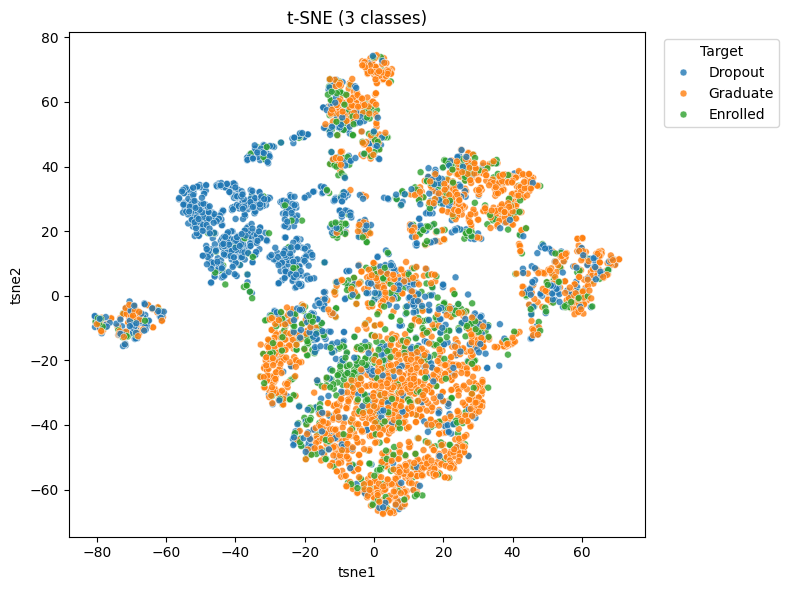

In [44]:
plot_df = tsne_raw_df.copy()
plot_df["label"] = y_3classes.values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="tsne1",
    y="tsne2",
    hue="label",
    palette="tab10",
    s=25,
    alpha=0.8,
)
plt.title("t-SNE (3 classes)")
plt.legend(title="Target", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

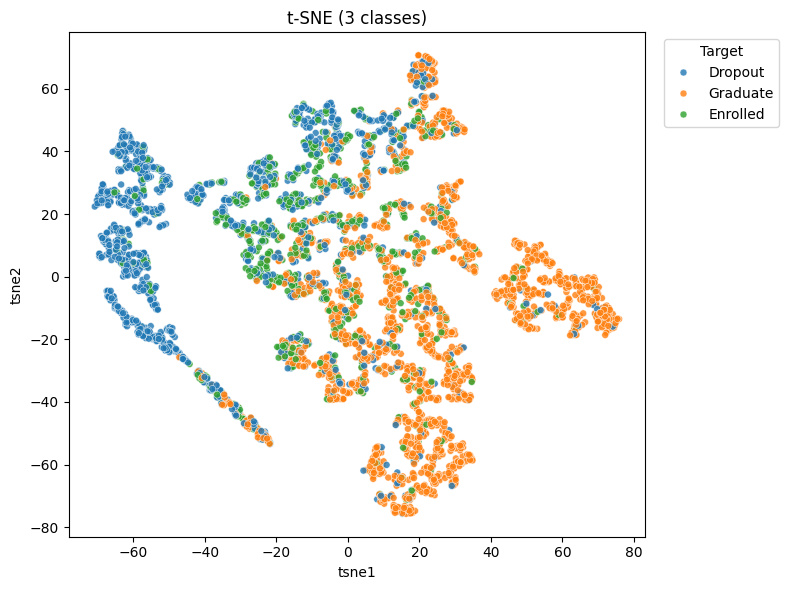

In [45]:
plot_df = tsne_df.copy()
plot_df["label"] = y_3classes.values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="tsne1",
    y="tsne2",
    hue="label",
    palette="tab10",
    s=25,
    alpha=0.8,
)
plt.title("t-SNE (3 classes)")
plt.legend(title="Target", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 4.1 Clustering

In [76]:
cluster_methods = {
    'kmeans': {},
    'kernel_kmeans': {},
    'agglomerative': {'linkage': 'ward'},
    'gmm': {},
}

cluster_rows = []
for method, kwargs in cluster_methods.items():
    model, labels = perform_clustering(
        X_pca, method=method, n_clusters=3, **kwargs
)
    labels = np.asarray(labels)
    effective_k = len(set(labels)) - (1 if -1 in labels else 0)
    noise_rate = float(np.mean(labels == -1)) if -1 in labels else 0.0

    metrics = evaluate_clustering(X_pca, labels, y_true=y_3classes)
    cluster_rows.append({
        'method': method,
        'effective_k': effective_k,
        'noise_rate': noise_rate,
        **metrics,
    })

cluster_results = pd.DataFrame(cluster_rows)
cluster_results = cluster_results.sort_values(
    by=['silhouette', 'ARI', 'NMI'], ascending=[False, False, False]
)
display(cluster_results.round(4))

,method,effective_k,noise_rate,silhouette,calinski_harabasz,davies_bouldin,db_inv,internal_score,ARI,NMI,external_score,score
0,kmeans,3,0.0,0.6077,5290.1723,0.6486,0.6066,0.7559,0.1957,0.1873,0.3926,0.5379
2,agglomerative,3,0.0,0.5910,5003.5753,0.7252,0.5796,0.7423,0.1801,0.1727,0.3814,0.5258
3,gmm,3,0.0,0.5493,3921.1819,1.0300,0.4926,0.6982,0.1803,0.1605,0.3753,0.5045
1,kernel_kmeans,3,0.0,0.1690,996.5342,1.3300,0.4292,0.5681,0.1983,0.1979,0.3985,0.4663


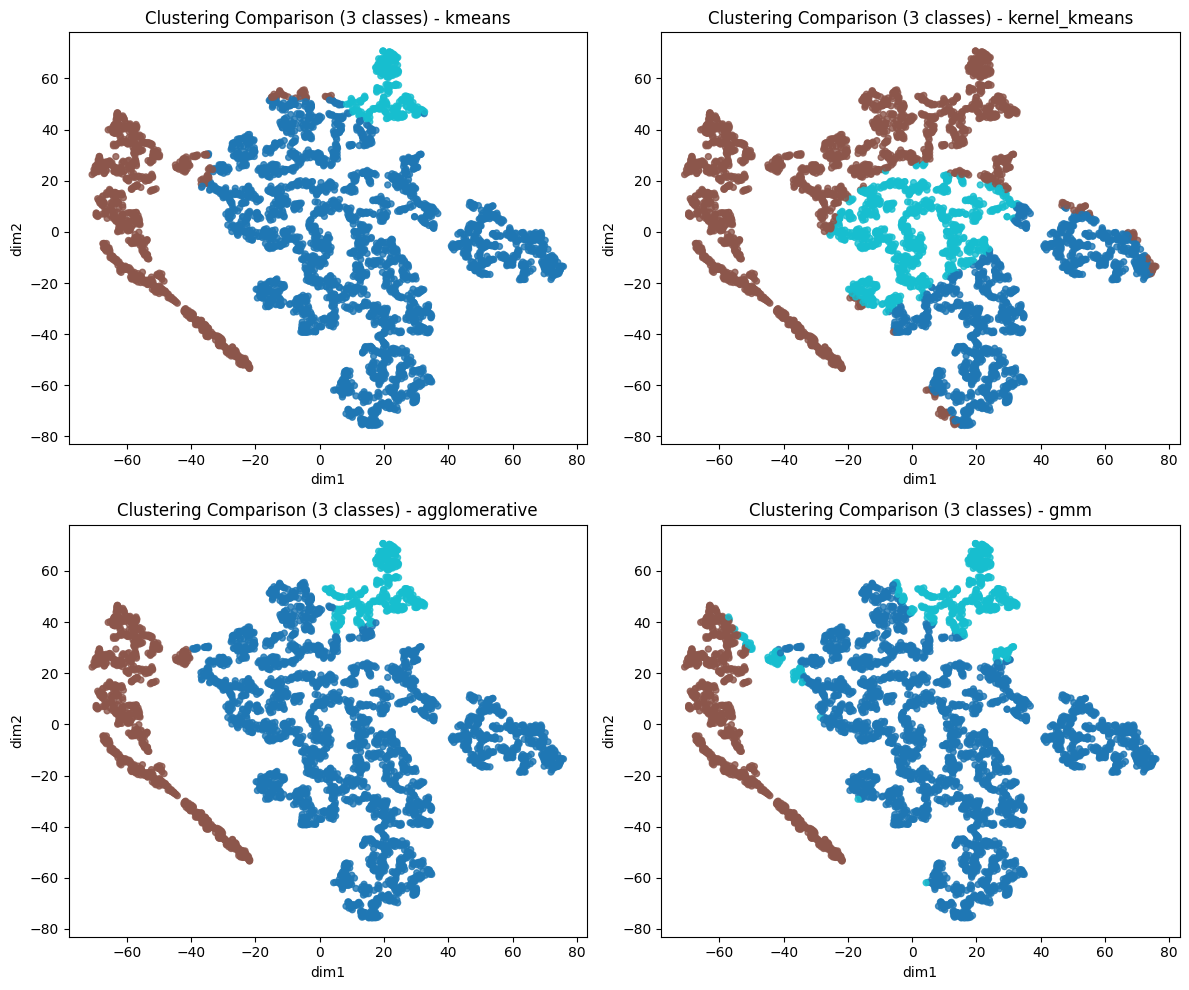

In [79]:
plot_cluster_comparison(
    X_cluster=X_pca,
    X_plot=tsne_df,
    methods=cluster_methods,
    n_clusters=3,
    title_prefix="Clustering Comparison (3 classes)"
)

### 4.2 Classification

In [86]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_3classes, test_size=0.30, random_state=42, stratify=y_3classes
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

# X_train_processed = preprocessor.fit_transform(X_train_raw)
# X_test_processed = preprocessor.transform(X_test_raw)
# X_train_dense = X_train_processed if isinstance(X_train_processed, pd.DataFrame) else pd.DataFrame(X_train_processed)
# PCA_dim = min(X_train_dense.shape[1], 50)
# pca = PCA(n_components=PCA_dim, random_state=42)
# X_train =pca.fit_transform(X_train_processed)
# X_test = pca.transform(X_test_processed)

model_specs = {
    'LogisticRegression': ('logistic', {}),
    'Perceptron': ('perceptron', {}),
    'SVM': ('svm', {}),
    'DecisionTree': ('decision_tree', {}),
    'RandomForest': ('random_forest', {}),
    'GradientBoosting': ('gradient_boosting', {}),
    'AdaBoost': ('adaboost', {}),
}

classification_rows = []
confusion_mats = {}
models = {}
for name, (method, kwargs) in model_specs.items():
    model = train_model(X_train, y_train, method=method, **kwargs)
    models[name] = model
    res = evaluate_classification(model, X_test, y_test)
    confusion_mats[name] = res.pop('confusion_matrix')
    res['model'] = name
    classification_rows.append(res)

classification_results = pd.DataFrame(classification_rows)
classification_results = classification_results.sort_values(
    by=['f1', 'accuracy'], ascending=[False, False]
).reset_index(drop=True)
display(classification_results.round(4))

d:\Workspace\school\DSAA2011\project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
d:\Workspace\school\DSAA2011\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,accuracy,precision,recall,f1,roc_auc,model
0,0.7779,0.7366,0.6887,0.7018,0.8770,RandomForest
1,0.7748,0.7200,0.6912,0.7004,0.8799,GradientBoosting
2,0.7342,0.6960,0.6985,0.6910,0.8780,SVM
3,0.7334,0.6891,0.6925,0.6870,0.8708,LogisticRegression
4,0.7523,0.6791,0.6365,0.6350,0.8482,AdaBoost
5,0.6837,0.6289,0.6173,0.6203,NaN,Perceptron
6,0.6875,0.6187,0.6189,0.6187,0.7282,DecisionTree


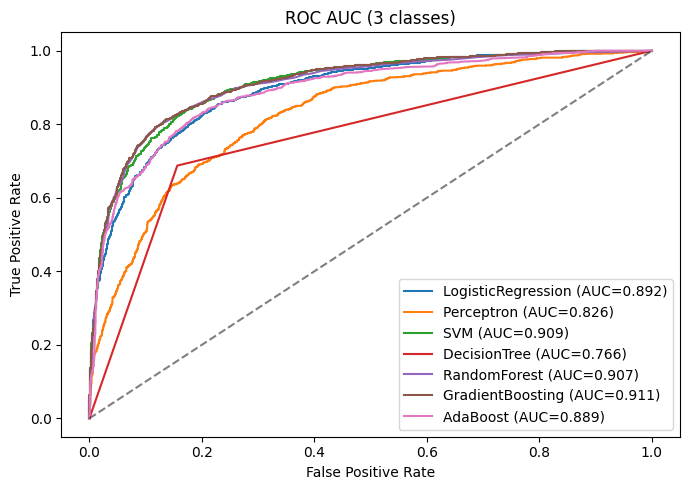

In [87]:
plot_roc_auc(
    models,
    X_test,
    y_test,
    title="ROC AUC (3 classes)"
)

## 5. Analysis of 2-Classes Task

In [48]:
y_2classes = df['Target'].map({'Dropout': 'Dropout', 'Graduate': 'Non-Dropout', 'Enrolled': 'Non-Dropout'})
print(f'Target distribution:')
for cls, cnt in y_2classes.value_counts().items():
    print(f'  {cls:12s}: {cnt:5d}  ({cnt / len(y_2classes) * 100:.1f} %)')

Target distribution:
  Non-Dropout :  3003  (67.9 %)
  Dropout     :  1421  (32.1 %)


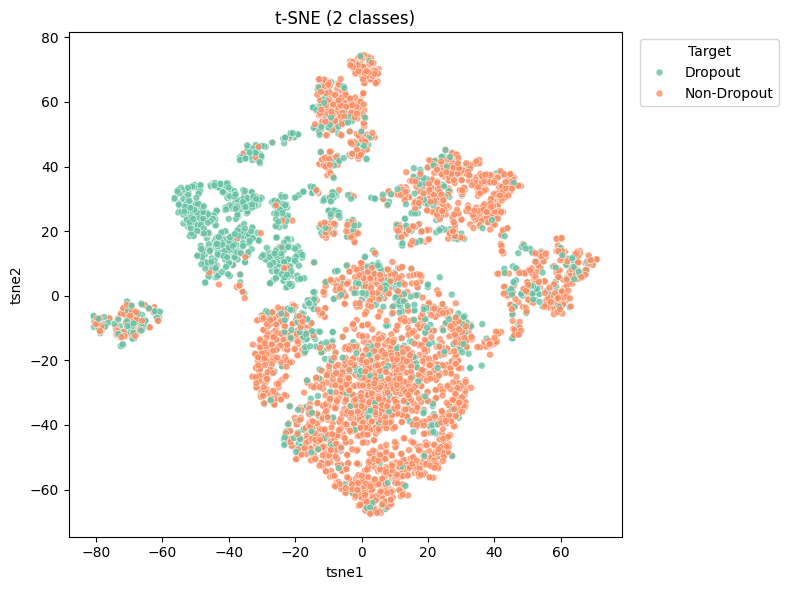

In [49]:
plot_df = tsne_raw_df.copy()
plot_df["label"] = y_2classes.values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="tsne1",
    y="tsne2",
    hue="label",
    palette="Set2",
    s=25,
    alpha=0.8,
)
plt.title("t-SNE (2 classes)")
plt.legend(title="Target", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

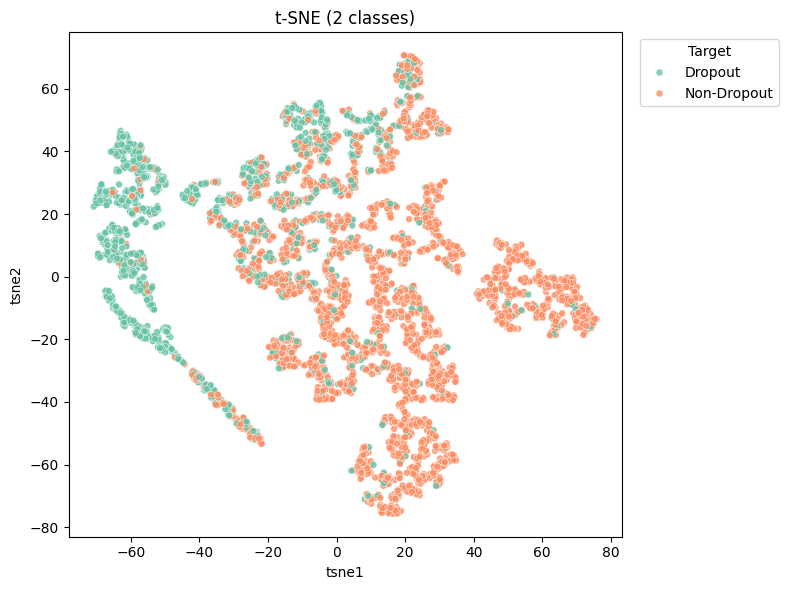

In [50]:
plot_df = tsne_df.copy()
plot_df["label"] = y_2classes.values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="tsne1",
    y="tsne2",
    hue="label",
    palette="Set2",
    s=25,
    alpha=0.8,
)
plt.title("t-SNE (2 classes)")
plt.legend(title="Target", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 5.1 Clustering

In [84]:
cluster_methods_2 = {
    'kmeans': {},
    'kernel_kmeans': {},
    'agglomerative': {'linkage': 'ward'},
    'gmm': {},
}

cluster_rows_2 = []
for method, kwargs in cluster_methods_2.items():
    model, labels = perform_clustering(
        X_pca, method=method, n_clusters=2, **kwargs
)
    labels = np.asarray(labels)
    effective_k = len(set(labels)) - (1 if -1 in labels else 0)
    noise_rate = float(np.mean(labels == -1)) if -1 in labels else 0.0

    metrics = evaluate_clustering(X_pca, labels, y_true=y_2classes)
    cluster_rows_2.append({
        'method': method,
        'effective_k': effective_k,
        'noise_rate': noise_rate,
        **metrics,
    })

cluster_results_2 = pd.DataFrame(cluster_rows_2)
cluster_results_2 = cluster_results_2.sort_values(
    by=['silhouette', 'ARI', 'NMI'], ascending=[False, False, False]
)
display(cluster_results_2.round(4))

,method,effective_k,noise_rate,silhouette,calinski_harabasz,davies_bouldin,db_inv,internal_score,ARI,NMI,external_score,score
2,agglomerative,2,0.0,0.6019,4997.4790,0.5821,0.6321,0.7616,0.3628,0.2593,0.4704,0.5868
3,gmm,2,0.0,0.5979,4768.7133,0.5760,0.6345,0.7602,0.3389,0.2412,0.4553,0.5773
0,kmeans,2,0.0,0.5945,5106.1780,0.6173,0.6183,0.7565,0.3880,0.2741,0.4841,0.5930
1,kernel_kmeans,2,0.0,0.2635,1496.8793,1.0844,0.4797,0.6142,0.0933,0.1723,0.3594,0.4614


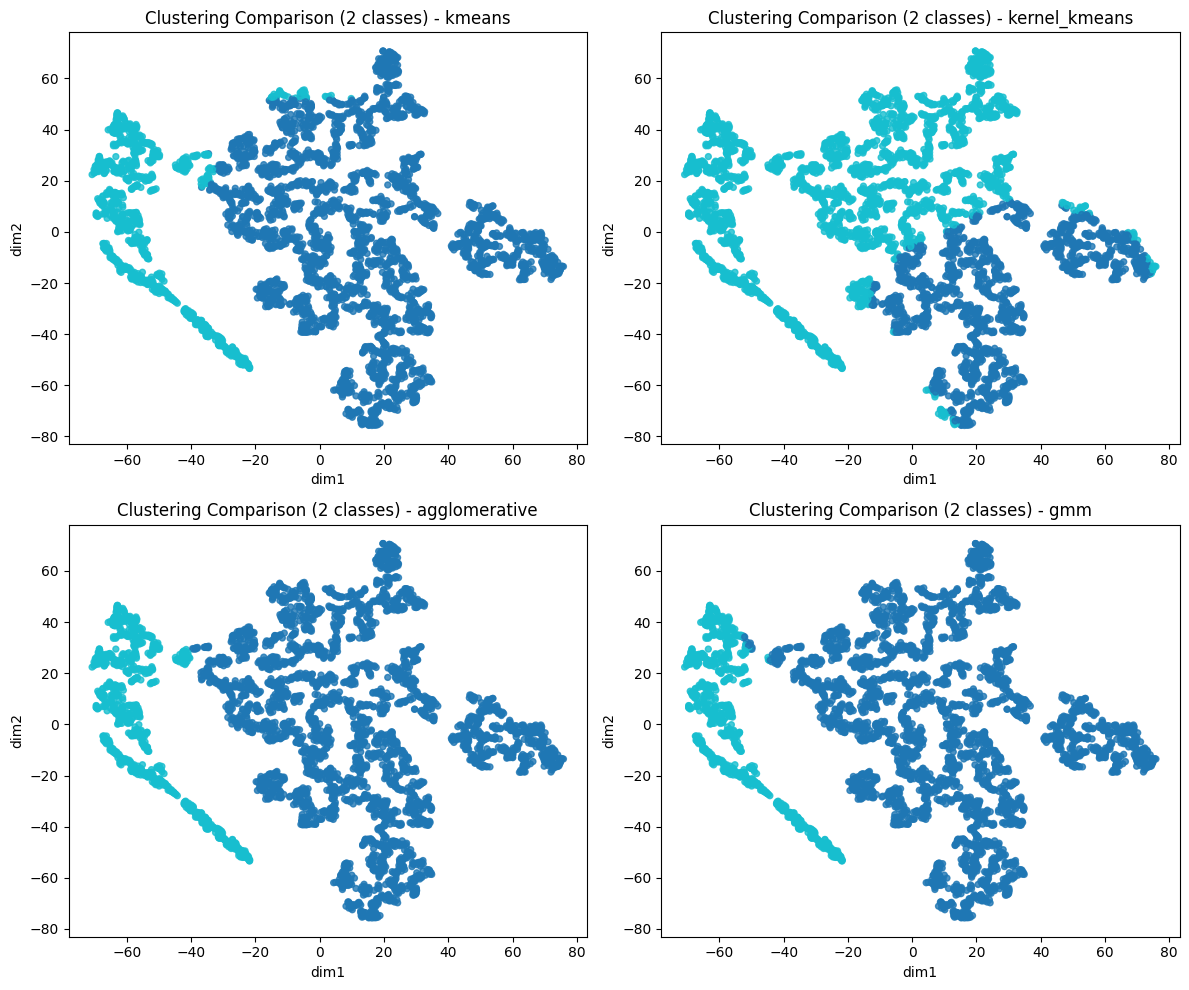

In [85]:
plot_cluster_comparison(
    X_cluster=X_pca,
    X_plot=tsne_df,
    methods=cluster_methods_2,
    n_clusters=2,
    title_prefix="Clustering Comparison (2 classes)"
)

### 5.2 Classification

In [80]:
X_train_raw_2, X_test_raw_2, y_train_2, y_test_2 = train_test_split(
    X, y_2classes, test_size=0.30, random_state=42, stratify=y_2classes
)

X_train_2 = preprocessor.fit_transform(X_train_raw_2)
X_test_2 = preprocessor.transform(X_test_raw_2)

model_specs_2 = {
    'LogisticRegression': ('logistic', {}),
    'Perceptron': ('perceptron', {}),
    'SVM': ('svm', {}),
    'DecisionTree': ('decision_tree', {}),
    'RandomForest': ('random_forest', {}),
    'GradientBoosting': ('gradient_boosting', {}),
    'AdaBoost': ('adaboost', {}),
}

classification_rows_2 = []
confusion_mats_2 = {}
models_2 = {}
for name, (method, kwargs) in model_specs_2.items():
    model = train_model(X_train_2, y_train_2, method=method, **kwargs)
    models_2[name] = model
    res = evaluate_classification(model, X_test_2, y_test_2)
    confusion_mats_2[name] = res.pop('confusion_matrix')
    res['model'] = name
    classification_rows_2.append(res)

classification_results_2 = pd.DataFrame(classification_rows_2)
classification_results_2 = classification_results_2.sort_values(
    by=['f1', 'accuracy'], ascending=[False, False]
).reset_index(drop=True)
display(classification_results_2.round(4))

d:\Workspace\school\DSAA2011\project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,accuracy,precision,recall,f1,roc_auc,model
0,0.8795,0.8759,0.8422,0.8559,0.9170,GradientBoosting
1,0.8712,0.8518,0.8540,0.8529,0.9139,SVM
2,0.8660,0.8441,0.8538,0.8486,0.9189,LogisticRegression
3,0.8645,0.8564,0.8256,0.8381,0.9111,RandomForest
4,0.8614,0.8479,0.8283,0.8368,0.9103,AdaBoost
5,0.8456,0.8211,0.8339,0.8267,NaN,Perceptron
6,0.7899,0.7594,0.7565,0.7579,0.7565,DecisionTree


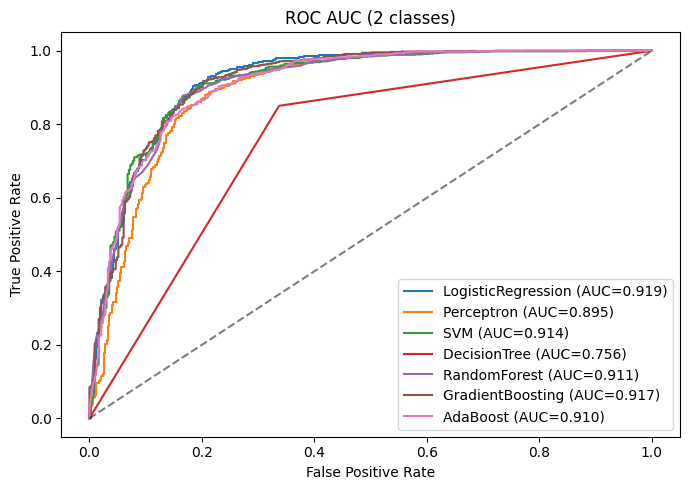

In [83]:
plot_roc_auc(
    models_2,
    X_test_2,
    y_test_2,
    title="ROC AUC (2 classes)"
)

## 6. Grid Search

In [53]:
model_grids = {

    # -------------------------
    # Linear Models
    # -------------------------
    'LogisticRegression': (
        'logistic',
        {
            "C": [0.01, 0.1, 1, 10, 100],
            "penalty": ["l2"],
            "solver": ["lbfgs"],
            "max_iter": [500, 1000, 2000, 5000]
        }
    ),

    'Perceptron': (
        'perceptron',
        {
            "alpha": [0.0001, 0.001, 0.01],
            "penalty": [None, "l2", "l1", "elasticnet"],
            "max_iter": [1000, 2000, 5000]
        }
    ),

    # -------------------------
    # Support Vector Machine
    # -------------------------
    'SVM': (
        'svm',
        {
            "C": [0.1, 1, 10, 100],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        }
    ),

    # -------------------------
    # Tree Models
    # -------------------------
    'DecisionTree': (
        'decision_tree',
        {
            "max_depth": [None, 3, 5, 10, 20],
            "min_samples_split": [2, 5, 10, 20],
            "min_samples_leaf": [1, 2, 5],
            "criterion": ["gini", "entropy"]
        }
    ),

    # -------------------------
    # Ensemble - Bagging
    # -------------------------
    'RandomForest': (
        'random_forest',
        {
            "n_estimators": [100, 200, 300],
            "max_depth": [None, 10, 20, 30],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 5],
            "max_features": ["sqrt", "log2"]
        }
    ),

    # -------------------------
    # Boosting
    # -------------------------
    'GradientBoosting': (
        'gradient_boosting',
        {
            "n_estimators": [100, 200, 300],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [2, 3, 5],
            "subsample": [0.8, 1.0]
        }
    ),

    'AdaBoost': (
        'adaboost',
        {
            "n_estimators": [50, 100, 200, 300],
            "learning_rate": [0.5, 1.0, 1.5],
        }
    )
}

In [ ]:
classification_rows = []
confusion_mats = {}
best_models = {}

for name, (method, param_grid) in model_grids.items():
    
    best_model, best_params, best_score = grid_search_classification(
        X_train,
        y_train,
        X_test,
        y_test,
        method=method,
        param_grid=param_grid
    )
    
    best_models[name] = best_model
    res = evaluate_classification(best_model, X_test, y_test)
    
    confusion_mats[name] = res.pop('confusion_matrix')
    res['model'] = name
    res['best_params'] = best_params
    
    classification_rows.append(res)

classification_results = pd.DataFrame(classification_rows)

classification_results = classification_results.sort_values(
    by=['f1', 'accuracy'],
    ascending=[False, False]
).reset_index(drop=True)

display(classification_results.round(4))

logistic | {'C': 0.01, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.6994
logistic | {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.6994
logistic | {'C': 0.01, 'max_iter': 2000, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.6994
logistic | {'C': 0.01, 'max_iter': 5000, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.6994
logistic | {'C': 0.1, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.7108
logistic | {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.7108
logistic | {'C': 0.1, 'max_iter': 2000, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.7108
logistic | {'C': 0.1, 'max_iter': 5000, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.7108
logistic | {'C': 1, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.7201
logistic | {'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.7201
logistic | {'C': 1, 'max_iter': 2000, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.7201
logistic | {'C': 1, 'max_iter': 5000,

,accuracy,precision,recall,f1,roc_auc,model,best_params
0,0.7869,0.7398,0.7156,0.7247,0.8872,RandomForest,"{'max_depth': 30, 'max_features': 'sqrt', 'min..."
1,0.7568,0.7246,0.7330,0.7201,0.8857,LogisticRegression,"{'C': 1, 'max_iter': 500, 'penalty': 'l2', 'so..."
2,0.7779,0.7263,0.7093,0.7160,0.8884,GradientBoosting,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
3,0.7508,0.7186,0.7254,0.7139,0.8829,SVM,"{'C': 100, 'gamma': 'scale', 'kernel': 'linear'}"
4,0.7575,0.7032,0.6929,0.6967,0.8539,AdaBoost,"{'learning_rate': 1.5, 'n_estimators': 100}"
5,0.7380,0.6823,0.6731,0.6767,0.8344,DecisionTree,"{'criterion': 'entropy', 'max_depth': 10, 'min..."
6,0.7199,0.6808,0.6771,0.6728,NaN,Perceptron,"{'alpha': 0.0001, 'max_iter': 1000, 'penalty':..."


In [ ]:
plot_roc_auc(
    best_models,
    X_test,
    y_test,
    title="ROC AUC (Grid Search, 3 classes)"
)

In [ ]:
classification_rows_2 = []
confusion_mats_2 = {}
best_models_2 = {}

for name, (method, param_grid) in model_grids.items():
    
    best_model, best_params, best_score = grid_search_classification(
        X_train_2,
        y_train_2,
        X_test_2,
        y_test_2,
        method=method,
        param_grid=param_grid
    )
    
    best_models_2[name] = best_model
    res = evaluate_classification(best_model, X_test_2, y_test_2)
    
    confusion_mats_2[name] = res.pop('confusion_matrix')
    res['model'] = name
    res['best_params'] = best_params
    
    classification_rows_2.append(res)
    
classification_results_2 = pd.DataFrame(classification_rows_2)

classification_results_2 = classification_results_2.sort_values(
    by=['f1', 'accuracy'],
    ascending=[False, False]
).reset_index(drop=True)

display(classification_results_2.round(4))

logistic | {'C': 0.01, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.8338
logistic | {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.8338
logistic | {'C': 0.01, 'max_iter': 2000, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.8338
logistic | {'C': 0.01, 'max_iter': 5000, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.8338
logistic | {'C': 0.1, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.8503
logistic | {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.8503
logistic | {'C': 0.1, 'max_iter': 2000, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.8503
logistic | {'C': 0.1, 'max_iter': 5000, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.8503
logistic | {'C': 1, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.8486
logistic | {'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.8486
logistic | {'C': 1, 'max_iter': 2000, 'penalty': 'l2', 'solver': 'lbfgs'} | F1=0.8486
logistic | {'C': 1, 'max_iter': 5000,

,accuracy,precision,recall,f1,roc_auc,model,best_params
0,0.8788,0.8701,0.8466,0.8567,0.9232,GradientBoosting,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
1,0.8712,0.8510,0.8564,0.8536,0.9154,SVM,"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}"
2,0.8720,0.8553,0.8490,0.8520,0.9139,RandomForest,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
3,0.8675,0.8458,0.8555,0.8503,0.9180,LogisticRegression,"{'C': 0.1, 'max_iter': 500, 'penalty': 'l2', '..."
4,0.8727,0.8633,0.8391,0.8494,0.9099,AdaBoost,"{'learning_rate': 1.5, 'n_estimators': 200}"
5,0.8554,0.8350,0.8325,0.8337,NaN,Perceptron,"{'alpha': 0.0001, 'max_iter': 1000, 'penalty':..."
6,0.8547,0.8367,0.8258,0.8308,0.8853,DecisionTree,"{'criterion': 'gini', 'max_depth': 3, 'min_sam..."


In [ ]:
plot_roc_auc(
    best_models_2,
    X_test_2,
    y_test_2,
    title="ROC AUC (Grid Search, 2 classes)"
)

## 7. Other Explorations

### 7.1 Feature Importance

### 7.2 Optimized Method

In [62]:
def train_optimized_model(X_train, y_train, method='rf', **kwargs):
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    from catboost import CatBoostClassifier

     # ===== XGBoost =====
    if method == 'xgboost':
        model = XGBClassifier(
            objective='multi:softprob',
            num_class=3,
            eval_metric='mlogloss',
            random_state=42,
            **kwargs
        )

    # ===== LightGBM =====
    elif method == 'lightgbm':
        model = LGBMClassifier(
            objective='multiclass',
            num_class=3,
            random_state=42,
            **kwargs
        )

    # ===== CatBoost =====
    elif method == 'catboost':
        model = CatBoostClassifier(
            loss_function='MultiClass',
            verbose=0,
            random_state=42,
            **kwargs
        )

    else:
        raise ValueError(f"Unexpected method: {method}")

    model.fit(X_train, y_train)
    return model

In [ ]:
# y_3classes = y_3classes.map({
#     'Dropout': 0,
#     'Graduate': 1,
#     'Enrolled': 2
# })

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_3classes, test_size=0.30, random_state=42, stratify=y_3classes
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

classification_rows = []
confusion_mats = {}
optimized_models = {}

optimized_model_specs = {
    'XGBoost': ('xgboost', {
        'n_estimators': 100,
        'max_depth': 6,
        'learning_rate': 0.1
    }),
    'LightGBM': ('lightgbm', {
        'n_estimators': 100,
        'max_depth': 6,
        'learning_rate': 0.1
    }),
    'CatBoost': ('catboost', {
        'n_estimators': 100,
        'max_depth': 6,
        'learning_rate': 0.1
    }),
}

for name, (method, kwargs) in optimized_model_specs.items():
    model = train_optimized_model(X_train, y_train, method=method, **kwargs)
    optimized_models[name] = model
    res = evaluate_classification(model, X_test, y_test)
    confusion_mats[name] = res.pop('confusion_matrix')
    res['model'] = name
    classification_rows.append(res)
    
classification_results = pd.DataFrame(classification_rows)
classification_results = classification_results.sort_values(
    by=['f1', 'accuracy'], ascending=[False, False]
).reset_index(drop=True)

display(classification_results.round(4))

d:\Workspace\school\DSAA2011\project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000584 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1963
[LightGBM] [Info] Number of data points in the train set: 3096, number of used features: 91
[LightGBM] [Info] Start training from score -1.136129
[LightGBM] [Info] Start training from score -0.694440
[LightGBM] [Info] Start training from score -1.717098
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

d:\Workspace\school\DSAA2011\project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Workspace\school\DSAA2011\project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,accuracy,precision,recall,f1,roc_auc,model
0,0.7741,0.7240,0.6972,0.7067,0.8859,LightGBM
1,0.7718,0.7174,0.6873,0.6970,0.8862,XGBoost
2,0.7756,0.7188,0.6854,0.6948,0.8841,CatBoost


In [ ]:
plot_roc_auc(
    optimized_models,
    X_test,
    y_test,
    title="ROC AUC (Optimized Models)"
)

### 7.3 Multi-Model Fusion